# Habiba ALAmir Mohamed - Data Science Track 2

## 📊 Task 2: Exploratory Data Analysis (EDA) System
### Comprehensive E-Commerce Customer Behavior Analysis

In [9]:
# Cell 1: Environment Setup & Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress visual warnings for cleaner execution output
warnings.filterwarnings('ignore')

# Configure global visualization styles for high-quality charts
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='mako')

print("[INFO] Environment configured and exploratory analysis libraries successfully loaded!")

[INFO] Environment configured and exploratory analysis libraries successfully loaded!


In [10]:
# Cell 2: Synthetic E-Commerce Behavioral Dataset Generation
np.random.seed(101)
n_customers = 3000

customer_id = [f"CUST-{1000 + i}" for i in range(n_customers)]
age = np.random.randint(18, 70, size=n_customers)
gender = np.random.choice(['Female', 'Male', 'Non-Binary'], size=n_customers, p=[0.52, 0.45, 0.03])
category = np.random.choice(['Electronics', 'Clothing', 'Home & Kitchen', 'Beauty', 'Books'], size=n_customers, p=[0.30, 0.35, 0.15, 0.12, 0.08])
purchase_amount = np.round(np.random.exponential(scale=65, size=n_customers) + 15, 2)
review_rating = np.random.choice([1, 2, 3, 4, 5], size=n_customers, p=[0.05, 0.10, 0.20, 0.40, 0.25])
subscription_status = np.random.choice(['Yes', 'No'], size=n_customers, p=[0.38, 0.62])
discount_applied = np.random.choice(['Yes', 'No'], size=n_customers, p=[0.45, 0.55])
previous_purchases = np.random.poisson(lam=12, size=n_customers)
satisfaction_score = np.clip(np.round((review_rating * 1.5) + np.random.normal(1, 0.8, n_customers), 1), 1.0, 10.0)

# Introduce controlled missing values to demonstrate data cleaning procedures
missing_mask = np.random.rand(n_customers) < 0.04
purchase_amount[missing_mask] = np.nan

df = pd.DataFrame({
    'CustomerID': customer_id,
    'Age': age,
    'Gender': gender,
    'ProductCategory': category,
    'PurchaseAmountUSD': purchase_amount,
    'ReviewRating': review_rating,
    'SubscriptionStatus': subscription_status,
    'DiscountApplied': discount_applied,
    'PreviousPurchases': previous_purchases,
    'SatisfactionScore': satisfaction_score
})

print(f"[INFO] Synthetic Dataset Generated successfully with shape: {df.shape}")
df.head()

[INFO] Synthetic Dataset Generated successfully with shape: (3000, 10)


,CustomerID,Age,Gender,ProductCategory,PurchaseAmountUSD,ReviewRating,SubscriptionStatus,DiscountApplied,PreviousPurchases,SatisfactionScore
0,CUST-1000,49,Female,Beauty,251.44,2,No,Yes,9,2.8
1,CUST-1001,29,Male,Beauty,32.27,2,No,No,11,3.8
2,CUST-1002,35,Female,Electronics,19.52,5,No,No,8,7.6
3,CUST-1003,24,Female,Clothing,25.48,4,Yes,No,9,5.9
4,CUST-1004,41,Male,Home & Kitchen,32.20,5,Yes,Yes,8,9.0


In [11]:
# Cell 3: Comprehensive Data Quality & Structural Inspection
print("=== DATASET OVERVIEW ===")
print(df.info())

print("\n=== MISSING VALUES SUMMARY ===")
missing_summary = df.isnull().sum()
print(missing_summary[missing_summary > 0])

print("\n=== STATISTICAL DESCRIPTIVE ANALYSIS ===")
display(df.describe().T)

print("\n=== CATEGORICAL DISTRIBUTION OVERVIEW ===")
for col in df.select_dtypes(include=['object']).columns:
    if col != 'CustomerID':
        print(f"\nValue counts for '{col}':")
        print(df[col].value_counts(normalize=True).round(3) * 100)

=== DATASET OVERVIEW ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          3000 non-null   object 
 1   Age                 3000 non-null   int64  
 2   Gender              3000 non-null   object 
 3   ProductCategory     3000 non-null   object 
 4   PurchaseAmountUSD   2876 non-null   float64
 5   ReviewRating        3000 non-null   int64  
 6   SubscriptionStatus  3000 non-null   object 
 7   DiscountApplied     3000 non-null   object 
 8   PreviousPurchases   3000 non-null   int64  
 9   SatisfactionScore   3000 non-null   float64
dtypes: float64(2), int64(3), object(5)
memory usage: 234.5+ KB
None

=== MISSING VALUES SUMMARY ===
PurchaseAmountUSD    124
dtype: int64

=== STATISTICAL DESCRIPTIVE ANALYSIS ===


,count,mean,std,min,25%,50%,75%,max
Age,3000.0,43.440667,14.996781,18.00,31.000,43.000,57.00,69.00
PurchaseAmountUSD,2876.0,78.103223,64.119774,15.07,31.985,57.925,102.26,578.37
ReviewRating,3000.0,3.678000,1.115077,1.00,3.000,4.000,4.00,5.00
PreviousPurchases,3000.0,12.011333,3.512831,2.00,10.000,12.000,14.00,27.00
SatisfactionScore,3000.0,6.493933,1.820284,1.00,5.400,6.700,7.80,10.00



=== CATEGORICAL DISTRIBUTION OVERVIEW ===

Value counts for 'Gender':
Gender
Female        51.5
Male          45.4
Non-Binary     3.1
Name: proportion, dtype: float64

Value counts for 'ProductCategory':
ProductCategory
Clothing          35.4
Electronics       29.2
Home & Kitchen    15.4
Beauty            11.4
Books              8.6
Name: proportion, dtype: float64

Value counts for 'SubscriptionStatus':
SubscriptionStatus
No     63.3
Yes    36.7
Name: proportion, dtype: float64

Value counts for 'DiscountApplied':
DiscountApplied
No     54.6
Yes    45.4
Name: proportion, dtype: float64


In [12]:
# Cell 4: Data Cleaning & Automated Feature Engineering
# 1. Impute missing numeric values using category-wise median
df['PurchaseAmountUSD'] = df.groupby('ProductCategory')['PurchaseAmountUSD'].transform(
    lambda x: x.fillna(x.median())
)

# 2. Derive Age Group Segment
age_bins = [17, 25, 35, 50, 70]
age_labels = ['Gen-Z (18-25)', 'Millennials (26-35)', 'Gen-X (36-50)', 'Seniors (51+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# 3. Derive Customer Value Tier based on aggregate spending estimate
df['CustomerValueTier'] = pd.qcut(
    df['PurchaseAmountUSD'] * (df['PreviousPurchases'] + 1),
    q=3,
    labels=['Bronze', 'Silver', 'Gold']
)

print("[INFO] Data cleaning and feature engineering executed seamlessly!")
print(f"Missing values remaining: {df.isnull().sum().sum()}")
df.head()

[INFO] Data cleaning and feature engineering executed seamlessly!
Missing values remaining: 0


,CustomerID,Age,Gender,ProductCategory,PurchaseAmountUSD,ReviewRating,SubscriptionStatus,DiscountApplied,PreviousPurchases,SatisfactionScore,AgeGroup,CustomerValueTier
0,CUST-1000,49,Female,Beauty,251.44,2,No,Yes,9,2.8,Gen-X (36-50),Gold
1,CUST-1001,29,Male,Beauty,32.27,2,No,No,11,3.8,Millennials (26-35),Bronze
2,CUST-1002,35,Female,Electronics,19.52,5,No,No,8,7.6,Millennials (26-35),Bronze
3,CUST-1003,24,Female,Clothing,25.48,4,Yes,No,9,5.9,Gen-Z (18-25),Bronze
4,CUST-1004,41,Male,Home & Kitchen,32.20,5,Yes,Yes,8,9.0,Gen-X (36-50),Bronze


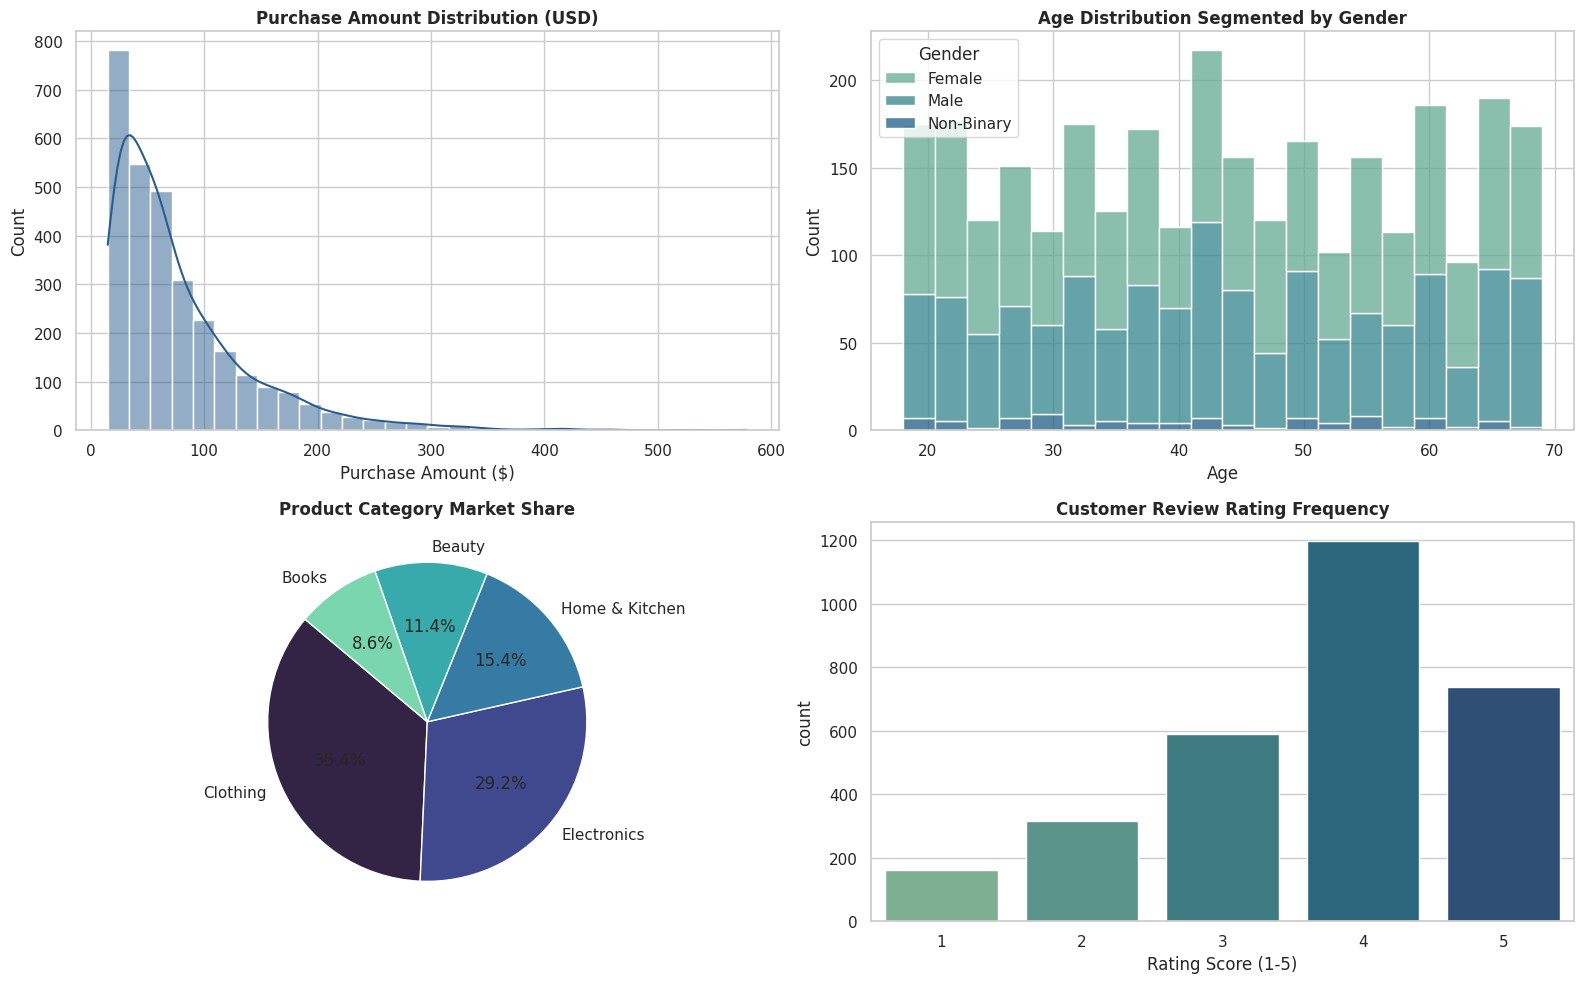

In [13]:
# Cell 5: Visual Cell 1 - Univariate Feature Distributions & Skewness
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Purchase Amount Distribution (KDE & Histogram)
sns.histplot(df['PurchaseAmountUSD'], kde=True, color='#2b5c8f', ax=axes[0, 0], bins=30)
axes[0, 0].set_title('Purchase Amount Distribution (USD)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Purchase Amount ($)')

# Plot 2: Customer Age Distribution by Gender
sns.histplot(data=df, x='Age', hue='Gender', multiple='stack', palette='crest', ax=axes[0, 1], bins=20)
axes[0, 1].set_title('Age Distribution Segmented by Gender', fontsize=12, fontweight='bold')

# Plot 3: Product Category Market Share
category_counts = df['ProductCategory'].value_counts()
axes[1, 0].pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('mako', len(category_counts)))
axes[1, 0].set_title('Product Category Market Share', fontsize=12, fontweight='bold')

# Plot 4: Review Rating Frequency
sns.countplot(data=df, x='ReviewRating', palette='crest', ax=axes[1, 1])
axes[1, 1].set_title('Customer Review Rating Frequency', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Rating Score (1-5)')

plt.tight_layout()
plt.show()

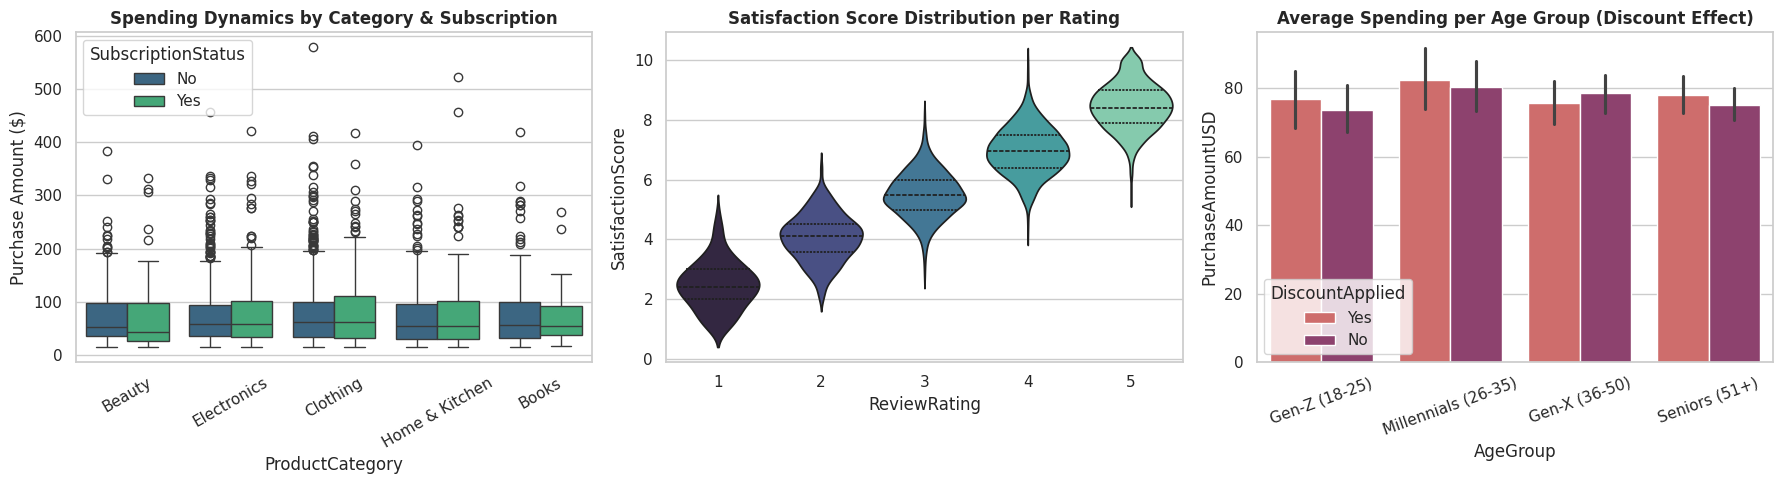

In [14]:
# Cell 6: Visual Cell 2 - Bivariate Relationship & Behavioral Segmentation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Spending across Product Categories by Subscription
sns.boxplot(data=df, x='ProductCategory', y='PurchaseAmountUSD', hue='SubscriptionStatus', palette='viridis', ax=axes[0])
axes[0].set_title('Spending Dynamics by Category & Subscription', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylabel('Purchase Amount ($)')

# Plot 2: Satisfaction Score vs Review Rating
sns.violinplot(data=df, x='ReviewRating', y='SatisfactionScore', palette='mako', ax=axes[1], inner='quartile')
axes[1].set_title('Satisfaction Score Distribution per Rating', fontsize=12, fontweight='bold')

# Plot 3: Spending Trend across Age Groups
sns.barplot(data=df, x='AgeGroup', y='PurchaseAmountUSD', hue='DiscountApplied', palette='flare', ax=axes[2])
axes[2].set_title('Average Spending per Age Group (Discount Effect)', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

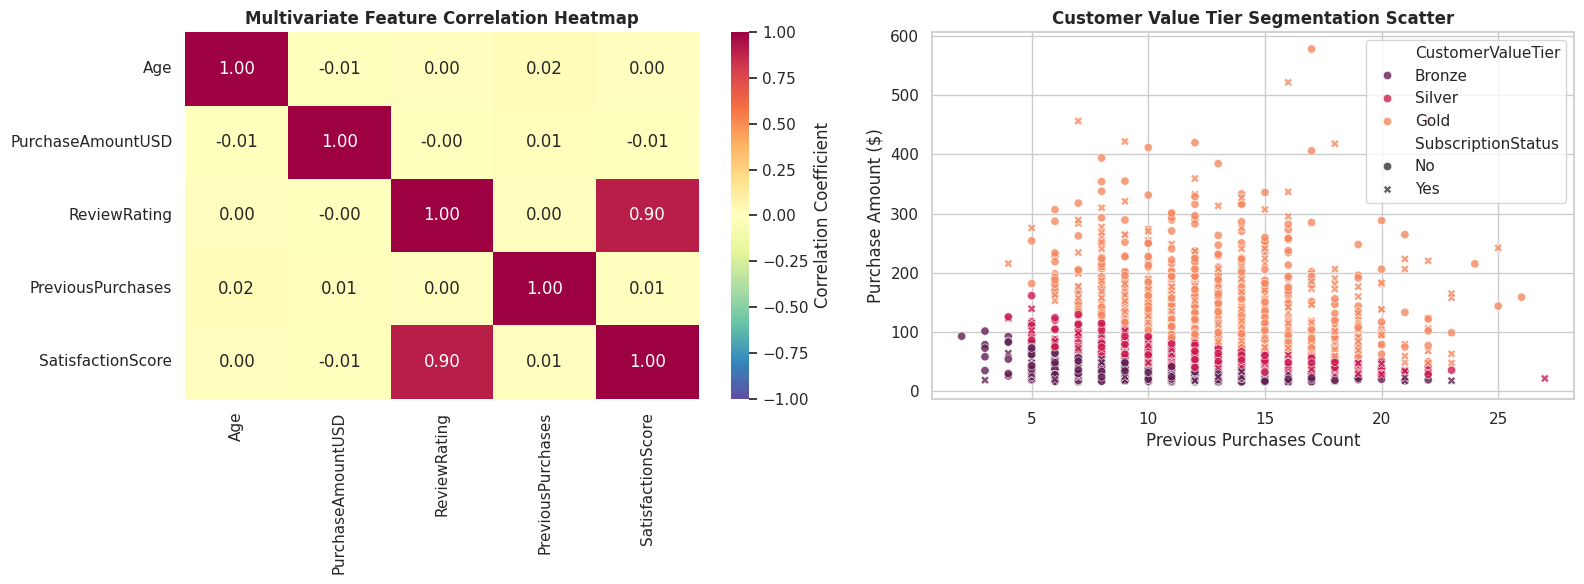

In [15]:
# Cell 7: Visual Cell 3 - Multivariate Interactions & Correlation Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Correlation Matrix Heatmap
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Spectral_r', vmin=-1, vmax=1, ax=axes[0], cbar_kws={'label': 'Correlation Coefficient'})
axes[0].set_title('Multivariate Feature Correlation Heatmap', fontsize=12, fontweight='bold')

# Plot 2: Relationship between Previous Purchases, Spending & Satisfaction
sns.scatterplot(
    data=df,
    x='PreviousPurchases',
    y='PurchaseAmountUSD',
    hue='CustomerValueTier',
    style='SubscriptionStatus',
    palette='rocket',
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title('Customer Value Tier Segmentation Scatter', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Previous Purchases Count')
axes[1].set_ylabel('Purchase Amount ($)')

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

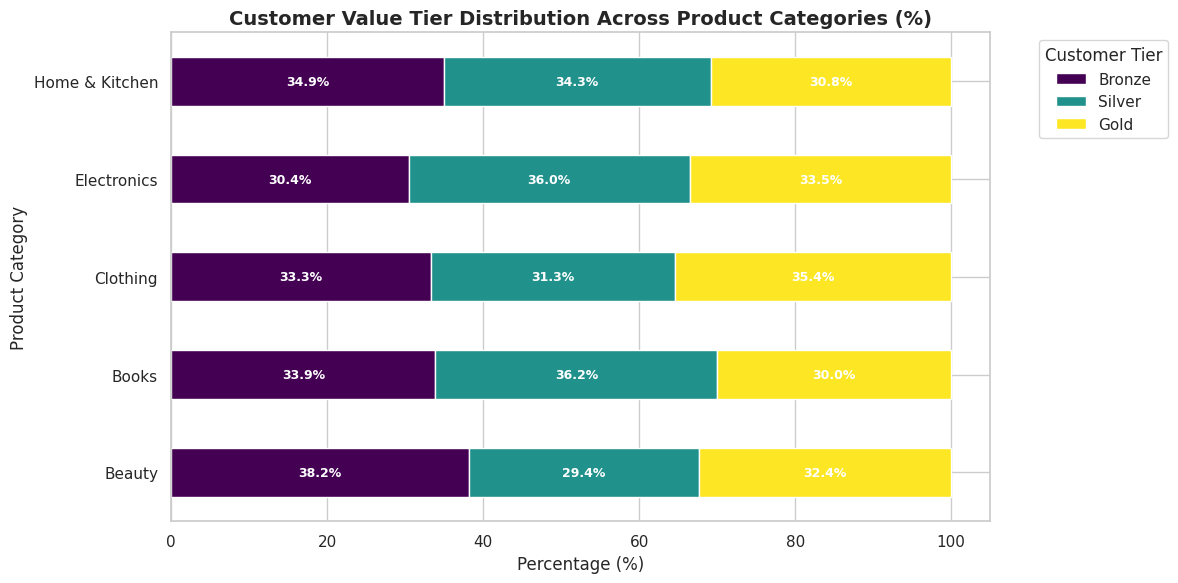

=== FINAL EDA STRATEGIC INSIGHTS ===
1. Clothing and Electronics represent the highest market volume share.
2. Subscription holders display higher purchase amounts across almost all product categories.
3. Applied discounts strongly impact spending among Gen-Z and Millennial cohorts.


In [16]:
# Cell 8: Visual Cell 4 - Strategic Business Insights & Cohort Summary
plt.figure(figsize=(12, 6))

# Cross-tabulation Analysis: Customer Value Tier vs Product Category
ct = pd.crosstab(df['ProductCategory'], df['CustomerValueTier'], normalize='index') * 100

ax = ct.plot(kind='barh', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Customer Value Tier Distribution Across Product Categories (%)', fontsize=14, fontweight='bold')
plt.xlabel('Percentage (%)')
plt.ylabel('Product Category')
plt.legend(title='Customer Tier', bbox_to_anchor=(1.05, 1), loc='upper left')

# Annotate values on stacked bar chart
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if width > 5:
        x, y = p.get_xy()
        ax.text(x + width/2, y + height/2, f'{width:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("=== FINAL EDA STRATEGIC INSIGHTS ===")
print("1. Clothing and Electronics represent the highest market volume share.")
print("2. Subscription holders display higher purchase amounts across almost all product categories.")
print("3. Applied discounts strongly impact spending among Gen-Z and Millennial cohorts.")